# S04.07 — Red Neuronal de Perceptrones Multicapa (MLP)
## Módulo 3, Tema 1: Introducción a Machine Learning — Subtema 4

**Target:** `prima_neta` — prima neta sintética (MXN) de la póliza de autos  
**Técnica:** `MLPRegressor` de scikit-learn (feed-forward, backpropagation, Adam)  
**Dataset:** Sintético v2 — 30,000 pólizas de seguros de autos

> **Nota importante:** `MLPRegressor` es una red neuronal feed-forward entrenada
> con retropropagación. No es equivalente a *deep learning* (arquitecturas profundas,
> convolucionales, recurrentes o de atención). Es la primera aproximación a redes
> neuronales dentro del ecosistema scikit-learn.

---

## 1. Contexto actuarial

### 1.1 Target: prima\_neta sintética

La variable `prima_neta` en este dataset es un **target sintético de tarificación**:
se generó mediante una función aditiva de las features del dataset más ruido,
diseñada para ilustrar regresión sobre una estructura predominantemente aditiva
con componente cuadrático.

> **Nota actuarial:** en la práctica, la prima pura suele relacionarse con
> frecuencia y severidad media (Prima pura ≈ Frecuencia × Severidad media).
> Ese **no** es el mecanismo de generación de este dataset sintético.
> `prima_neta` aquí no deriva de `n_siniestros` ni de `monto_siniestro`.

Los modelos lineales (OLS, GLM) han dominado la tarificación por su interpretabilidad.
Sin embargo, las redes neuronales pueden capturar **interacciones no lineales** y
**efectos combinados** entre variables de riesgo sin especificarlos manualmente.

### 1.2 Ventajas y desafíos del MLP en seguros

**Ventajas:**
- Aproximador universal: bajo condiciones adecuadas de arquitectura y activación, una red puede
  aproximar funciones continuas sobre dominios compactos con precisión arbitraria
  (Cybenko, 1989; Hornik et al., 1989). El teorema de aproximación universal no garantiza
  que el entrenamiento encuentre esa aproximación ni que generalice.
- Puede aprender interacciones entre `edad`, `plan`, `nivel_riesgo_asignado`, etc., sin especificarlas manualmente; que efectivamente las aprenda depende de los datos, la arquitectura y el entrenamiento.
- No requiere especificación manual de términos cuadráticos (como en S04.02).

**Desafíos:**
- Se recomienda fuertemente el escalamiento de features y — para regresión — también del target.
- Sensible a hiperparámetros (arquitectura, `alpha`, `learning_rate_init`).
- Menor interpretabilidad que regresión lineal: sin coeficientes directamente comunicables.
- Convergencia no garantizada; requiere `max_iter` suficiente y early stopping.

### 1.3 Separación de targets

Este notebook predice `prima_neta`. Los otros targets —`siniestro_alto`, `n_siniestros`,
`monto_siniestro`, `status_poliza`— **no se usan como features**.

> *Fuentes principales:* Géron (2022) Cap. 10 §10.1–§10.2; Murphy (2022) Cap. 13; scikit-learn User Guide v1.9.0.

## 2. Fundamento matemático

### 2.1 Arquitectura feed-forward

Una red feed-forward tiene capas: **entrada** → **ocultas** → **salida**.

Cada capa $l$ recibe la activación de la capa anterior:

$$\mathbf{z}^{(l)} = \mathbf{W}^{(l)} \mathbf{a}^{(l-1)} + \mathbf{b}^{(l)}$$
$$\mathbf{a}^{(l)} = \varphi\!\left(\mathbf{z}^{(l)}\right)$$

donde $\mathbf{W}^{(l)}$ es la matriz de pesos, $\mathbf{b}^{(l)}$ el vector de sesgos
y $\varphi$ la función de activación.

**Capa de entrada:** $\mathbf{a}^{(0)} = \mathbf{x}$ (features escaladas).

**Capas ocultas:** activan con ReLU.

**Capa de salida (regresión):** sin activación no lineal → salida lineal.

### 2.2 Función de activación ReLU

$$\text{ReLU}(z) = \max(0, z)$$

- Computacionalmente eficiente. Gradiente: 1 si $z > 0$; 0 si $z < 0$;
  en $z = 0$ la derivada no está definida matemáticamente — scikit-learn
  adopta la convención de subgradiente 0 en $z=0$ en su implementación.
- Mitiga el problema del gradiente saturado de `tanh` y `sigmoid` en su región positiva.
- Puede presentar neuronas inactivas (*dying ReLU*) si muchas unidades quedan en $z \leq 0$.
- Por defecto en `MLPRegressor`.

### 2.3 Objetivo de entrenamiento (sklearn `MLPRegressor`)

Para `loss="squared_error"` (regresión) sin sample weights, el objetivo que sklearn
minimiza internamente es aproximadamente:

$$\mathcal{L}_{\text{skl}}(\boldsymbol{\theta}) = \frac{1}{2n} \sum_{i=1}^n \left(\tilde{y}_i - \hat{\tilde{y}}_i\right)^2 + \frac{\alpha}{2n} \sum_l \|\mathbf{W}^{(l)}\|_F^2$$

donde $\tilde{y}_i = (y_i - \mu_y)/\sigma_y$ es el target **estandarizado** (post `TransformedTargetRegressor`).

**La curva `loss_curve_` registra este objetivo de entrenamiento, no el MSE de evaluación.**
El MSE de evaluación (para métricas RMSE, R²) se calcula en las unidades originales (MXN),
después de invertir el escalamiento del target.

Para evaluar el desempeño del modelo usamos:
$$\text{MSE}_{\text{eval}} = \frac{1}{n} \sum_{i=1}^n \left(y_i^{\text{orig}} - \hat{y}_i^{\text{orig}}\right)^2$$

### 2.4 Retropropagación y regla de la cadena

Los gradientes $\nabla_{\mathbf{W}^{(l)}}\mathcal{L}$ se calculan
mediante **retropropagación** (backpropagation) usando errores de capa $\boldsymbol{\delta}$:

$$\boldsymbol{\delta}^{(L)} = \nabla_{\mathbf{z}^{(L)}}\mathcal{L}$$

$$\boldsymbol{\delta}^{(l)} = \bigl((\mathbf{W}^{(l+1)})^\top\boldsymbol{\delta}^{(l+1)}\bigr)\odot\varphi'(\mathbf{z}^{(l)})$$

$$\nabla_{\mathbf{W}^{(l)}}\mathcal{L} = \boldsymbol{\delta}^{(l)}(\mathbf{a}^{(l-1)})^\top$$

donde $\odot$ es el producto de Hadamard (elemento a elemento). Las fórmulas corresponden a la propagación por una observación; en minibatch se promedian sobre el batch.

### 2.5 Optimizador Adam

Adam combina momentum y escala adaptativa por parámetro:

$$\mathbf{W}^{(l)} \leftarrow \mathbf{W}^{(l)} - \eta \cdot \hat{\mathbf{m}} / (\sqrt{\hat{\mathbf{v}}} + \epsilon)$$

### 2.6 Regularización L2

En `MLPRegressor`, el parámetro `alpha` controla la penalización L2 sobre los pesos
(dividida entre el número de muestras en la implementación de sklearn):

$$\text{penalización} = \frac{\alpha}{2n} \sum_l \|\mathbf{W}^{(l)}\|_F^2$$

### 2.7 Early stopping en sklearn MLPRegressor

Con `early_stopping=True` y una tarea de **regresión**, sklearn:
- Reserva `validation_fraction` del conjunto de entrenamiento como validación interna.
- Calcula el **R²** de esa fracción de validación en cada época (`validation_scores_`).
- Detiene el entrenamiento si el R² no mejora al menos `tol` durante `n_iter_no_change` épocas consecutivas.
- Restaura los pesos del mejor epoch (máximo R² de validación).

> **Importante:** para regresión, `validation_scores_` contiene R², **no** MSE ni pérdida de validación.
> La curva de pérdida (`loss_curve_`) y los scores de validación (`validation_scores_`) son escalas distintas.

## 3. Carga del dataset

In [1]:
import sys
from pathlib import Path

_candidates = [
    Path.cwd() / "",
    Path.cwd().parent / "",
    Path.cwd().parent.parent / "",
]
_src_path = next(
    (p for p in _candidates if (p / "simulate_portfolio_v2.py").exists()),
    None,
)
if _src_path is None:
    raise FileNotFoundError(
        "No se encontró simulate_portfolio_v2.py. "
        "Ejecutar desde la raíz del proyecto o desde content/notebooks/."
    )
sys.path.insert(0, str(_src_path))

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from simulate_portfolio_v2 import (
    simulate_auto_insurance_portfolio_v2,
    FEATURE_COLUMNS,
    TARGET_COLUMNS,
)

SEED = 20260618
N    = 30_000
NAVY = "#003B5C"
GOLD = "#C8A33A"
RED  = "#C0392B"

plt.rcParams.update({"figure.dpi": 100, "font.size": 11})
sns.set_theme(style="whitegrid")
warnings.filterwarnings("ignore", category=FutureWarning)

df = simulate_auto_insurance_portfolio_v2(n_policies=N, seed=SEED)
print(f"Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")

Dataset cargado: 30,000 filas × 24 columnas


## 4. Preparación: features, target y escalamiento

### 4.1 Separación features / target

El target es `prima_neta`. Los features son las columnas 2–16 (FEATURE_COLUMNS).
Ningún otro target puede usarse como feature.

### 4.2 ¿Por qué escalar el target en MLP?

El optimizador Adam ajusta los pesos en el espacio de la función de pérdida MSE.
La celda siguiente calcula la media, desviación estándar y $E[y^2]$ reales de
`prima_neta` sobre el dataset cargado (cálculo dinámico, no valores de ejecuciones
anteriores). $E[y^2]$ es el MSE de un predictor inicial igual a cero — una referencia
de escala, no necesariamente el MSE exacto en la inicialización real del MLP.
Si `prima_neta` tiene una escala grande, partir de un objetivo sin escalar puede
dificultar la optimización o requerir ajustar la tasa de aprendizaje.

Al escalar el target a media≈0 y varianza≈1:
- Los gradientes tienden a ser más estables desde la primera iteración.
- `learning_rate_init` por defecto funciona mejor con esta escala.
- La función de pérdida de la curva de convergencia es comparable entre arquitecturas.

`TransformedTargetRegressor` aplica la transformación y su inversa automáticamente:
`predict()` devuelve predicciones en las unidades originales (MXN).

In [2]:
TARGET = "prima_neta"

NUMERIC_FEATURES = [
    "anio_poliza", "mes_emision", "edad",
    "num_renovaciones", "antiguedad_vehiculo",
    "suma_asegurada", "deducible_pct",
]
CAT_FEATURES = [
    "sexo", "estado_civil", "region", "plan",
    "tipo_vehiculo", "forma_pago", "canal_venta",
    "nivel_riesgo_asignado",
]

X_raw = df[FEATURE_COLUMNS]
y     = df[TARGET]

# Verificaciones de leakage
for t in TARGET_COLUMNS:
    assert t not in X_raw.columns, f"Leakage: {t} en X_raw"
assert "id_poliza_sin" not in X_raw.columns
print("✓ Sin leakage: ningún target ni id_poliza_sin en X_raw")
print(f"  Features numéricas : {len(NUMERIC_FEATURES)}")
print(f"  Features categóricas: {len(CAT_FEATURES)}")

print(f"\nDistribución de {TARGET}:")
print(f"  Media:  {y.mean():,.1f} MXN")
print(f"  Median: {y.median():,.1f} MXN")
print(f"  Std:    {y.std():,.1f} MXN")
print(f"  Min:    {y.min():,.1f} MXN")
print(f"  Max:    {y.max():,.1f} MXN")
print(f"  E[y²]:  {np.mean(y.values ** 2):.3e}")
print("          (MSE de un predictor inicial igual a cero — referencia de escala,")
print("           no necesariamente el MSE exacto en la inicialización real del MLP)")

✓ Sin leakage: ningún target ni id_poliza_sin en X_raw
  Features numéricas : 7
  Features categóricas: 8

Distribución de prima_neta:
  Media:  10,172.1 MXN
  Median: 9,545.0 MXN
  Std:    4,147.7 MXN
  Min:    1,261.2 MXN
  Max:    44,072.9 MXN
  E[y²]:  1.207e+08
          (MSE de un predictor inicial igual a cero — referencia de escala,
           no necesariamente el MSE exacto en la inicialización real del MLP)


## 5. Separación train/test y split de validación

El flujo de datos tiene tres capas:

1. **Split externo (30,000):** 80% train (24,000) + 20% test (6,000), reproducible con `random_state=SEED`.
2. **Split de validación (dentro de train):** 80% train_core (19,200) + 20% validation (4,800),
   usado **únicamente** para seleccionar la configuración del MLP (Sección 7b).
3. **Test fijo (6,000):** evaluado **una sola vez** con el modelo final (Sección 10).

Esta partición es compatible con la de S04.01–S04.11, permitiendo comparar RMSE directamente
(misma semilla, mismo `random_state`).

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.20, random_state=SEED
)
print(f"Train: {X_train.shape[0]:,} obs.  |  Test: {X_test.shape[0]:,} obs.")
print(f"\nEsta partición es idéntica a la de S04.01 (OLS) y S04.04–S04.11 (árboles/ensambles).")
print("Permite comparaciones directas de RMSE entre modelos.")

Train: 24,000 obs.  |  Test: 6,000 obs.

Esta partición es idéntica a la de S04.01 (OLS) y S04.04–S04.11 (árboles/ensambles).
Permite comparaciones directas de RMSE entre modelos.


In [4]:
## 5b. Split de validación (dentro de train) — para selección de configuración MLP

# Dividimos las 24,000 obs. de train en train_core (80%) y validation (20%).
# El test set (6,000) no se toca en esta etapa.
X_train_core, X_val, y_train_core, y_val = train_test_split(
    X_train, y_train, test_size=0.20, random_state=SEED
)
print(f"Split interno de train:")
print(f"  Train core (selección): {X_train_core.shape[0]:,} obs.")
print(f"  Validation (selección): {X_val.shape[0]:,} obs.")
print(f"  Test (evaluación final, intocado): {X_test.shape[0]:,} obs.")
print()
print("Las 3 configuraciones MLP se evaluarán únicamente en validation.")
print("El test set se evaluará UNA sola vez con el modelo final seleccionado.")

Split interno de train:
  Train core (selección): 19,200 obs.
  Validation (selección): 4,800 obs.
  Test (evaluación final, intocado): 6,000 obs.

Las 3 configuraciones MLP se evaluarán únicamente en validation.
El test set se evaluará UNA sola vez con el modelo final seleccionado.


## 6. Preprocesador compartido

In [5]:
# Preprocesador para MLP/OLS: OHE con drop="first" (no son métodos basados en distancia,
# a diferencia de SVM con kernel RBF en S04.06 — ahí drop="first" introduce una geometría
# arbitraria; aquí no aplica esa objeción). Cada pipeline recibe una instancia FRESCA de
# esta factory — un ColumnTransformer ya ajustado por un pipeline no debe reutilizarse en otro.
def make_mlp_preprocessor() -> ColumnTransformer:
    """Crea una instancia nueva del preprocesador para MLP y OLS."""
    return ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), NUMERIC_FEATURES),
            ("cat", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False),
             CAT_FEATURES),
        ],
        remainder="drop",
    )

# Verificar dimensión del espacio transformado — instancia de verificación, no reutilizada en pipelines
_pre_check = make_mlp_preprocessor().fit(X_train)
n_features_out = _pre_check.transform(X_train).shape[1]
print(f"Espacio OHE: {n_features_out} features de entrada al MLP")
print(f"  Numéricas (escaladas):   {len(NUMERIC_FEATURES)}")
print(f"  Categóricas (OHE − 1):  {n_features_out - len(NUMERIC_FEATURES)}")

Espacio OHE: 30 features de entrada al MLP
  Numéricas (escaladas):   7
  Categóricas (OHE − 1):  23


## 7. Modelo baseline: regresión lineal (referencia en validación)

Ajustamos una regresión lineal (OLS) preliminar sobre `train_core`/`validation`, con el
mismo preprocesador (factory) que usará el MLP, para tener una referencia de desempeño
lineal sin tocar el test. El ajuste final de OLS sobre `X_train` completo, comparable
directamente con el MLP, se realiza en la Sección 10 junto con la evaluación en test.

In [6]:
# Regresión Lineal (OLS) — referencia en validación (sin tocar el test)
#
# Esta es una referencia preliminar para contextualizar la selección de configuración
# MLP en la Sección 7b: se entrena en train_core y se evalúa SOLO en validation.
# El ajuste final de OLS (sobre X_train completo) y su evaluación en test se realizan
# en la Sección 10, junto con la evaluación final del MLP — no antes (protocolo de test).
pipeline_lr_val = Pipeline([
    ("preprocessor", make_mlp_preprocessor()),  # instancia fresca — sin estado compartido
    ("lr", LinearRegression()),
])
pipeline_lr_val.fit(X_train_core, y_train_core)

y_lr_val    = pipeline_lr_val.predict(X_val)
rmse_lr_val = np.sqrt(mean_squared_error(y_val, y_lr_val))
r2_lr_val   = r2_score(y_val, y_lr_val)

print("Regresión Lineal (OLS) — referencia en validación (train_core/val, test intocado):")
print(f"  RMSE validation: {rmse_lr_val:,.1f} MXN  |  R² validation: {r2_lr_val:.4f}")
print()

# Diagnóstico numérico: número de condición — ambas matrices construidas sobre X_train,
# con la MISMA codificación categórica; la única diferencia es el escalamiento de las
# numéricas (comparación controlada, no usa el test set).
_pre_unscaled = ColumnTransformer(
    transformers=[
        ("num", "passthrough", NUMERIC_FEATURES),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False),
         CAT_FEATURES),
    ],
    remainder="drop",
)
X_unscaled_mat = _pre_unscaled.fit_transform(X_train)
cond_unscaled  = np.linalg.cond(X_unscaled_mat)
rank_unscaled  = np.linalg.matrix_rank(X_unscaled_mat)

X_scaled_mat = make_mlp_preprocessor().fit_transform(X_train)
cond_scaled  = np.linalg.cond(X_scaled_mat)
rank_scaled  = np.linalg.matrix_rank(X_scaled_mat)

print("Número de condición — ambas matrices sobre X_train, misma codificación categórica")
print("(OHE drop='first'); única diferencia: escalamiento de las variables numéricas.")
print(f"  Sin escalar numéricas — cond: {cond_unscaled:.2e}  | rank: {rank_unscaled}  | cols: {X_unscaled_mat.shape[1]}")
print(f"  Con StandardScaler    — cond: {cond_scaled:.2f}    | rank: {rank_scaled}  | cols: {X_scaled_mat.shape[1]}")
print()
print("OLS es teóricamente invariante bajo transformaciones lineales no singulares del")
print("espacio de features, dado rango y precisión adecuados. Las diferencias observadas")
print("en el número de condición reflejan estabilidad numérica y rango efectivo en punto")
print("flotante — no implican un cambio en el espacio lineal teórico subyacente.")

Regresión Lineal (OLS) — referencia en validación (train_core/val, test intocado):
  RMSE validation: 714.3 MXN  |  R² validation: 0.9688

Número de condición — ambas matrices sobre X_train, misma codificación categórica
(OHE drop='first'); única diferencia: escalamiento de las variables numéricas.
  Sin escalar numéricas — cond: 1.98e+07  | rank: 30  | cols: 30
  Con StandardScaler    — cond: 8.79    | rank: 30  | cols: 30

OLS es teóricamente invariante bajo transformaciones lineales no singulares del
espacio de features, dado rango y precisión adecuados. Las diferencias observadas
en el número de condición reflejan estabilidad numérica y rango efectivo en punto
flotante — no implican un cambio en el espacio lineal teórico subyacente.


## 7b. Selección de configuración MLP — evaluación en validation (sin consultar test)

Antes de entrenar el modelo final, evaluamos tres configuraciones de arquitectura y
regularización **únicamente en el conjunto de validación** (4,800 obs. de `X_val`).
El test set (6,000 obs.) no se consulta en esta etapa.

Protocolo:
1. Entrenar cada configuración sobre `X_train_core` (19,200 obs.).
2. Evaluar RMSE en `X_val` (4,800 obs.).
3. Seleccionar la configuración con menor RMSE de validación.
4. Reajustar la configuración seleccionada sobre el `X_train` completo (24,000 obs.).
5. Evaluar el modelo final en `X_test` una sola vez (Sección 10).

In [7]:
configuraciones_val = [
    {"hidden_layer_sizes": (64, 32),  "alpha": 0.001, "label": "(64,32) α=0.001  [base]"},
    {"hidden_layer_sizes": (128, 64), "alpha": 0.001, "label": "(128,64) α=0.001  [más parámetros]"},
    {"hidden_layer_sizes": (64, 32),  "alpha": 0.010, "label": "(64,32) α=0.010  [más regularización]"},
]

print("Evaluación de configuraciones MLP — RMSE en validation (n=4,800):")
print("(Entrenamiento en train_core n=19,200 | Test intocado)")
print()

resultados_val = []
for cfg in configuraciones_val:
    _inner = Pipeline([
        ("preprocessor", make_mlp_preprocessor()),  # instancia fresca — sin estado compartido
        ("mlp", MLPRegressor(
            hidden_layer_sizes=cfg["hidden_layer_sizes"],
            activation="relu", solver="adam",
            alpha=cfg["alpha"], learning_rate_init=0.001,
            max_iter=500, early_stopping=True,
            validation_fraction=0.10, n_iter_no_change=20,
            batch_size="auto", random_state=SEED, verbose=False,
        )),
    ])
    _model = TransformedTargetRegressor(regressor=_inner, transformer=StandardScaler())
    _model.fit(X_train_core, y_train_core)
    _y_val_pred = _model.predict(X_val)
    _rmse_val   = np.sqrt(mean_squared_error(y_val, _y_val_pred))
    _r2_val     = r2_score(y_val, _y_val_pred)
    _n_iter     = _model.regressor_.named_steps["mlp"].n_iter_
    resultados_val.append({
        "label": cfg["label"],
        "hidden_layer_sizes": cfg["hidden_layer_sizes"],
        "alpha": cfg["alpha"],
        "rmse_val": _rmse_val,
        "r2_val": _r2_val,
        "n_iter": _n_iter,
    })
    print(f"  {cfg['label']:<40} RMSE_val={_rmse_val:,.1f}  R²_val={_r2_val:.4f}  épocas={_n_iter}")

# Selección: configuración con menor RMSE de validación
best_val = min(resultados_val, key=lambda d: d["rmse_val"])
print(f"\n→ Configuración seleccionada: {best_val['label']}")
print(f"  RMSE validation = {best_val['rmse_val']:,.1f} MXN  |  R² validation = {best_val['r2_val']:.4f}")
print()
print("Esta configuración se reajustará en la Sección 8 sobre X_train completo (24,000 obs.).")
print("El test set NO se ha consultado todavía.")

Evaluación de configuraciones MLP — RMSE en validation (n=4,800):
(Entrenamiento en train_core n=19,200 | Test intocado)

  (64,32) α=0.001  [base]                  RMSE_val=645.1  R²_val=0.9745  épocas=43
  (128,64) α=0.001  [más parámetros]       RMSE_val=655.5  R²_val=0.9737  épocas=48
  (64,32) α=0.010  [más regularización]    RMSE_val=637.5  R²_val=0.9751  épocas=43

→ Configuración seleccionada: (64,32) α=0.010  [más regularización]
  RMSE validation = 637.5 MXN  |  R² validation = 0.9751

Esta configuración se reajustará en la Sección 8 sobre X_train completo (24,000 obs.).
El test set NO se ha consultado todavía.


## 8. Red neuronal MLP — entrenamiento final con configuración seleccionada

### 8.1 Arquitectura

La configuración seleccionada en la Sección 7b (menor RMSE de validación) se reentrena
ahora sobre el conjunto completo de entrenamiento (`X_train`, 24,000 obs.):

- **Entrada:** $p$ features (post-OHE, escaladas)
- **Capas ocultas:** según configuración seleccionada (activación ReLU)
- **Salida:** 1 neurona, sin activación (regresión → $\hat{y} \in \mathbb{R}$)

### 8.2 Escalamiento del target

`TransformedTargetRegressor` aplica `StandardScaler` al target antes de entrenar
y la inversión automáticamente al predecir. El MLP ve `prima_neta` estandarizada;
`predict()` devuelve predicciones en MXN originales.

### 8.3 Objetivo de entrenamiento (sklearn MLPRegressor)

Para `loss="squared_error"` (por defecto en regresión) sin sample weights, el
objetivo que sklearn minimiza es aproximadamente:

$$\mathcal{L}_{\text{skl}}(\boldsymbol{\theta}) = \frac{1}{2n} \sum_{i=1}^n \left(\tilde{y}_i - \hat{\tilde{y}}_i\right)^2 + \frac{\alpha}{2n} \sum_l \|\mathbf{W}^{(l)}\|_F^2$$

donde $\tilde{y}_i = (y_i - \mu_y)/\sigma_y$ es el target **estandarizado** (misma notación que §2.3 y que la
imagen `fml_l2_reg.png` del PPTX). El factor $\frac{1}{2n}$ (en lugar de $\frac{1}{n}$)
es un detalle de implementación. La curva `loss_curve_` registra este objetivo de entrenamiento,
**no es exactamente MSE** de evaluación. Las métricas RMSE/MAE/R² se calculan después de
invertir el escalamiento del target.

In [8]:
# Entrenamiento final: configuración seleccionada, reajuste sobre X_train completo (24,000 obs.)
mlp_inner = Pipeline([
    ("preprocessor", make_mlp_preprocessor()),  # instancia fresca — sin estado compartido
    ("mlp", MLPRegressor(
        hidden_layer_sizes=best_val["hidden_layer_sizes"],
        activation="relu",
        solver="adam",
        alpha=best_val["alpha"],
        learning_rate_init=0.001,
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.10,
        n_iter_no_change=20,
        batch_size="auto",
        random_state=SEED,
        verbose=False,
    )),
])

# TransformedTargetRegressor escala prima_neta antes de entrenar
mlp_model = TransformedTargetRegressor(
    regressor=mlp_inner,
    transformer=StandardScaler(),
)

print(f"Entrenando MLP con configuración seleccionada: {best_val['label']}")
print(f"Datos de entrenamiento: X_train completo ({X_train.shape[0]:,} obs.)")
mlp_model.fit(X_train, y_train)

# Extraer el MLPRegressor para acceder a loss_curve_ y validation_scores_
mlp_raw = mlp_model.regressor_.named_steps["mlp"]

print(f"\nConvergencia:")
print(f"  Iteraciones realizadas: {mlp_raw.n_iter_}")
print(f"  Iteraciones máximas:    {mlp_raw.max_iter}")
print(f"  early_stopping activo:  {mlp_raw.early_stopping}")
if mlp_raw.n_iter_ < mlp_raw.max_iter:
    print(f"  → Convergió antes del máximo")
else:
    print(f"  → Alcanzó max_iter sin converger completamente")
print(f"  Objetivo final (train interno, escala estandarizada): {mlp_raw.loss_:.6f}")

# Nota sobre early stopping en sklearn MLPRegressor:
# Con early_stopping=True y una tarea de regresión, sklearn monitorea el R² en
# validation_fraction. Se detiene si el R² no mejora en n_iter_no_change iteraciones.
# (No monitorea la "pérdida de validación": validation_scores_ contiene R², no MSE.)
if hasattr(mlp_raw, "validation_scores_") and mlp_raw.validation_scores_ is not None:
    print(f"  R² de validación interna (último): {mlp_raw.validation_scores_[-1]:.4f}")
    print(f"  R² de validación interna (máx):   {max(mlp_raw.validation_scores_):.4f}")

Entrenando MLP con configuración seleccionada: (64,32) α=0.010  [más regularización]
Datos de entrenamiento: X_train completo (24,000 obs.)

Convergencia:
  Iteraciones realizadas: 40
  Iteraciones máximas:    500
  early_stopping activo:  True
  → Convergió antes del máximo
  Objetivo final (train interno, escala estandarizada): 0.011519
  R² de validación interna (último): 0.9763
  R² de validación interna (máx):   0.9767


## 9. Curva de pérdida y convergencia

Early stopping monitorea R² de validación (no la pérdida de validación).
  R² máximo: 0.9767 (época 28)
  R² final:  0.9763


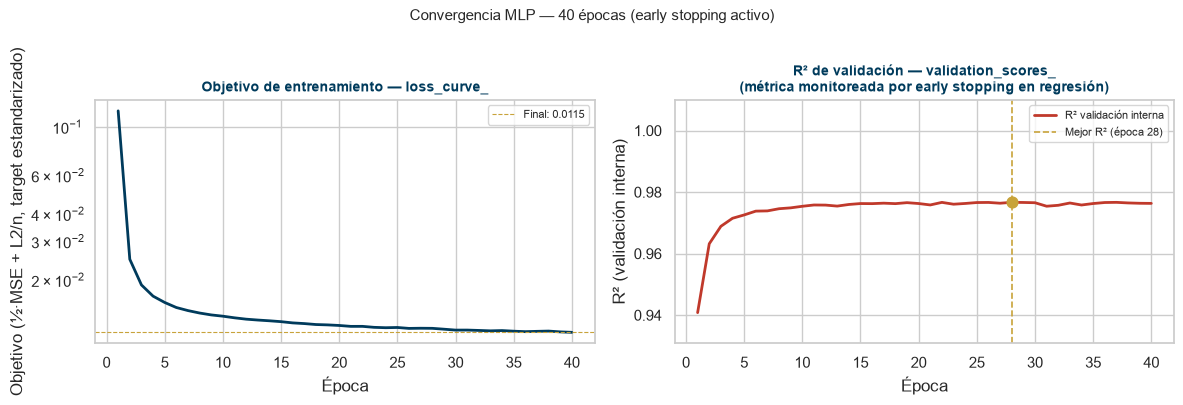


Curva loss_curve_: objetivo ½·MSE + L2/n sobre target estandarizado (NO es RMSE en MXN).
  Épocas: 40  |  Inicial: 0.1182  |  Final: 0.011519
  Reducción: 90.3%


In [9]:
loss_curve   = mlp_raw.loss_curve_
val_scores   = mlp_raw.validation_scores_ if hasattr(mlp_raw, "validation_scores_") else None
n_epochs     = len(loss_curve)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Panel 1: objetivo de entrenamiento (loss_curve_)
ax1 = axes[0]
ax1.plot(range(1, n_epochs + 1), loss_curve, color=NAVY, linewidth=2.0)
ax1.set_xlabel("Época")
ax1.set_ylabel("Objetivo (½·MSE + L2/n, target estandarizado)")
ax1.set_title("Objetivo de entrenamiento — loss_curve_",
              fontsize=10, color=NAVY, fontweight="bold")
ax1.set_yscale("log")
ax1.axhline(loss_curve[-1], color=GOLD, linewidth=0.8, linestyle="--",
            label=f"Final: {loss_curve[-1]:.4f}")
ax1.legend(fontsize=8)

# Panel 2: R² de validación interna (validation_scores_)
ax2 = axes[1]
if val_scores is not None:
    best_epoch = int(np.argmax(val_scores)) + 1
    ax2.plot(range(1, len(val_scores) + 1), val_scores,
             color=RED, linewidth=2.0, label="R² validación interna")
    ax2.axvline(best_epoch, color=GOLD, linewidth=1.2, linestyle="--",
                label=f"Mejor R² (época {best_epoch})")
    ax2.scatter([best_epoch], [max(val_scores)],
                color=GOLD, s=60, zorder=5)
    ax2.set_xlabel("Época")
    ax2.set_ylabel("R² (validación interna)")
    ax2.set_title("R² de validación — validation_scores_\n"
                  "(métrica monitoreada por early stopping en regresión)",
                  fontsize=10, color=NAVY, fontweight="bold")
    ax2.legend(fontsize=8)
    ax2.set_ylim([max(0, min(val_scores) - 0.01), 1.01])
    print(f"Early stopping monitorea R² de validación (no la pérdida de validación).")
    print(f"  R² máximo: {max(val_scores):.4f} (época {best_epoch})")
    print(f"  R² final:  {val_scores[-1]:.4f}")
else:
    ax2.text(0.5, 0.5, "validation_scores_ no disponible",
             ha="center", va="center", transform=ax2.transAxes)

plt.suptitle(f"Convergencia MLP — {n_epochs} épocas (early stopping activo)",
             fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

print(f"\nCurva loss_curve_: objetivo ½·MSE + L2/n sobre target estandarizado (NO es RMSE en MXN).")
print(f"  Épocas: {n_epochs}  |  Inicial: {loss_curve[0]:.4f}  |  Final: {loss_curve[-1]:.6f}")
print(f"  Reducción: {(1 - loss_curve[-1]/loss_curve[0])*100:.1f}%")

## 10. Evaluación final: métricas train y test

In [10]:
# OLS final: se entrena aquí sobre X_train completo con una instancia fresca del
# preprocesador (P4). El OLS de la Sección 7 (pipeline_lr_val) usó train_core/val y
# nunca tocó el test — era solo una referencia para contextualizar la selección del MLP.
# A partir de aquí, ni OLS ni MLP vuelven a consultarse contra el test: se reutilizan
# las predicciones guardadas (y_lr_test, y_mlp_test) en las secciones siguientes.
pipeline_lr = Pipeline([
    ("preprocessor", make_mlp_preprocessor()),  # instancia fresca — sin estado compartido
    ("lr", LinearRegression()),
])
pipeline_lr.fit(X_train, y_train)

y_lr_train  = pipeline_lr.predict(X_train)
y_lr_test   = pipeline_lr.predict(X_test)
y_mlp_train = mlp_model.predict(X_train)
y_mlp_test  = mlp_model.predict(X_test)

rmse_lr_train = np.sqrt(mean_squared_error(y_train, y_lr_train))
rmse_lr_test  = np.sqrt(mean_squared_error(y_test,  y_lr_test))
mae_lr_test   = mean_absolute_error(y_test, y_lr_test)
r2_lr_train   = r2_score(y_train, y_lr_train)
r2_lr_test    = r2_score(y_test,  y_lr_test)

rmse_mlp_train = np.sqrt(mean_squared_error(y_train, y_mlp_train))
rmse_mlp_test  = np.sqrt(mean_squared_error(y_test,  y_mlp_test))
mae_mlp_test   = mean_absolute_error(y_test, y_mlp_test)
r2_mlp_train   = r2_score(y_train, y_mlp_train)
r2_mlp_test    = r2_score(y_test,  y_mlp_test)

# Verificación: OLS de validación (Sección 7), OLS final y MLP usan instancias de
# preprocesador independientes (sin estado compartido) — P4
assert pipeline_lr_val.named_steps["preprocessor"] is not pipeline_lr.named_steps["preprocessor"]
assert pipeline_lr.named_steps["preprocessor"] is not mlp_model.regressor_.named_steps["preprocessor"]
print("✓ Preprocesadores de OLS (validación), OLS (final) y MLP son instancias independientes")
print()

print("=" * 60)
print("MÉTRICAS FINALES — Test set (n=6,000)")
print("(Evaluado una sola vez — no fue usado en selección)")
print("=" * 60)
print()
header = f"{'Modelo':<35} {'RMSE test':>10} {'MAE test':>10} {'R² test':>8} {'R² train':>9}"
print(header)
print("-" * len(header))
print(f"{'OLS (esta partición)':<35} {rmse_lr_test:>10,.1f} {mae_lr_test:>10,.1f} "
      f"{r2_lr_test:>8.4f} {r2_lr_train:>9.4f}")

mlp_nombre = f"MLP {best_val['label']}"
print(f"{mlp_nombre:<35} {rmse_mlp_test:>10,.1f} {mae_mlp_test:>10,.1f} "
      f"{r2_mlp_test:>8.4f} {r2_mlp_train:>9.4f}")
print()
print(f"Configuración MLP seleccionada: {best_val['label']}")
print(f"  RMSE_validation = {best_val['rmse_val']:,.1f} MXN  |  R²_validation = {best_val['r2_val']:.4f}")
print(f"OLS de referencia en validación (Sección 7): RMSE_validation = {rmse_lr_val:,.1f} MXN")
print()
print("Referencia (unidades anteriores, misma partición base):")
print("  RF max_features=1.0:  RMSE ≈ 808 MXN  |  R² ≈ 0.964")
print("  GBM flexible:         RMSE ≈ 693 MXN  |  R² ≈ 0.974")
print()
rmse_diff = rmse_lr_test - rmse_mlp_test
print(f"MLP vs OLS (esta partición): diferencia de {abs(rmse_diff):,.1f} MXN "
      f"({'MLP tiene menor RMSE' if rmse_diff > 0 else 'OLS tiene menor RMSE'})")
print()
print("Nota sobre la diferencia con S04.01 (OLS con RMSE≈752 MXN):")
print("  • S04.01 usó variables numéricas SIN StandardScaler.")
print("  • Sin escalar, variables de distintas magnitudes (suma_asegurada: ~270,000 MXN")
print("    vs. mes_emision: 1–12) producen una matriz X con número de condición más alto")
print("    (ver diagnóstico en la Sección 7), lo que puede deteriorar la precisión")
print("    numérica del solver de OLS.")
print("  • El pipeline local aplica StandardScaler a las variables numéricas,")
print("    reduciendo el número de condición y mejorando la estabilidad.")
print("  • El escalamiento reduce considerablemente el número de condición (diagnóstico en la Sección 7).")
print("    OLS es teóricamente invariante bajo transformaciones lineales no singulares del espacio")
print("    de features, dado rango y precisión adecuados. La diferencia observada en RMSE entre")
print("    S04.01 (sin StandardScaler) y este OLS está asociada al preprocesamiento y a la")
print("    estabilidad numérica; pero S04.01 y S04.07 también difieren en implementación y en el")
print("    orden/categoría de referencia del OHE — no puede atribuirse exclusivamente al escalamiento.")
print("    El diagnóstico de condición demuestra mejor acondicionamiento, no causalidad exclusiva.")
print()
print("Nota metodológica: el baseline adecuado para comparar con MLP es el OLS de esta")
print("partición (mismo preprocesamiento). La referencia S04.01 (RMSE≈752) usa preprocesa-")
print("miento diferente (sin StandardScaler en numéricas) y no es estrictamente homogénea.")

✓ Preprocesadores de OLS (validación), OLS (final) y MLP son instancias independientes

MÉTRICAS FINALES — Test set (n=6,000)
(Evaluado una sola vez — no fue usado en selección)

Modelo                               RMSE test   MAE test  R² test  R² train
----------------------------------------------------------------------------
OLS (esta partición)                     737.6      577.2   0.9700    0.9689
MLP (64,32) α=0.010  [más regularización]      633.1      501.6   0.9779    0.9792

Configuración MLP seleccionada: (64,32) α=0.010  [más regularización]
  RMSE_validation = 637.5 MXN  |  R²_validation = 0.9751
OLS de referencia en validación (Sección 7): RMSE_validation = 714.3 MXN

Referencia (unidades anteriores, misma partición base):
  RF max_features=1.0:  RMSE ≈ 808 MXN  |  R² ≈ 0.964
  GBM flexible:         RMSE ≈ 693 MXN  |  R² ≈ 0.974

MLP vs OLS (esta partición): diferencia de 104.6 MXN (MLP tiene menor RMSE)

Nota sobre la diferencia con S04.01 (OLS con RMSE≈752 MXN):
  •

## 11. Real vs predicho

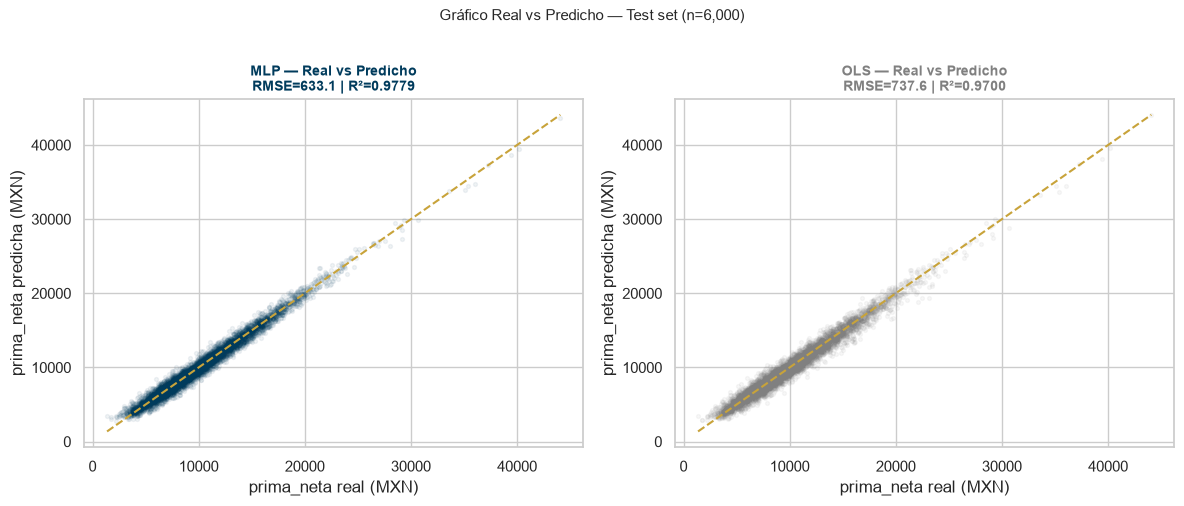

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── MLP ────────────────────────────────────────────────────────────────────
ax = axes[0]
ax.scatter(y_test, y_mlp_test, alpha=0.06, s=8, color=NAVY)
lim = [min(y_test.min(), y_mlp_test.min()),
       max(y_test.max(), y_mlp_test.max())]
ax.plot(lim, lim, "--", color=GOLD, linewidth=1.5)
ax.set_xlabel("prima_neta real (MXN)")
ax.set_ylabel("prima_neta predicha (MXN)")
ax.set_title(f"MLP — Real vs Predicho\nRMSE={rmse_mlp_test:,.1f} | R²={r2_mlp_test:.4f}",
             fontsize=10, color=NAVY, fontweight="bold")

# ── OLS ────────────────────────────────────────────────────────────────────
ax = axes[1]
ax.scatter(y_test, y_lr_test, alpha=0.06, s=8, color="gray")
ax.plot(lim, lim, "--", color=GOLD, linewidth=1.5)
ax.set_xlabel("prima_neta real (MXN)")
ax.set_ylabel("prima_neta predicha (MXN)")
ax.set_title(f"OLS — Real vs Predicho\nRMSE={rmse_lr_test:,.1f} | R²={r2_lr_test:.4f}",
             fontsize=10, color="gray", fontweight="bold")

plt.suptitle("Gráfico Real vs Predicho — Test set (n=6,000)",
             fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

## 12. Residuales: distribución y heterocedasticidad

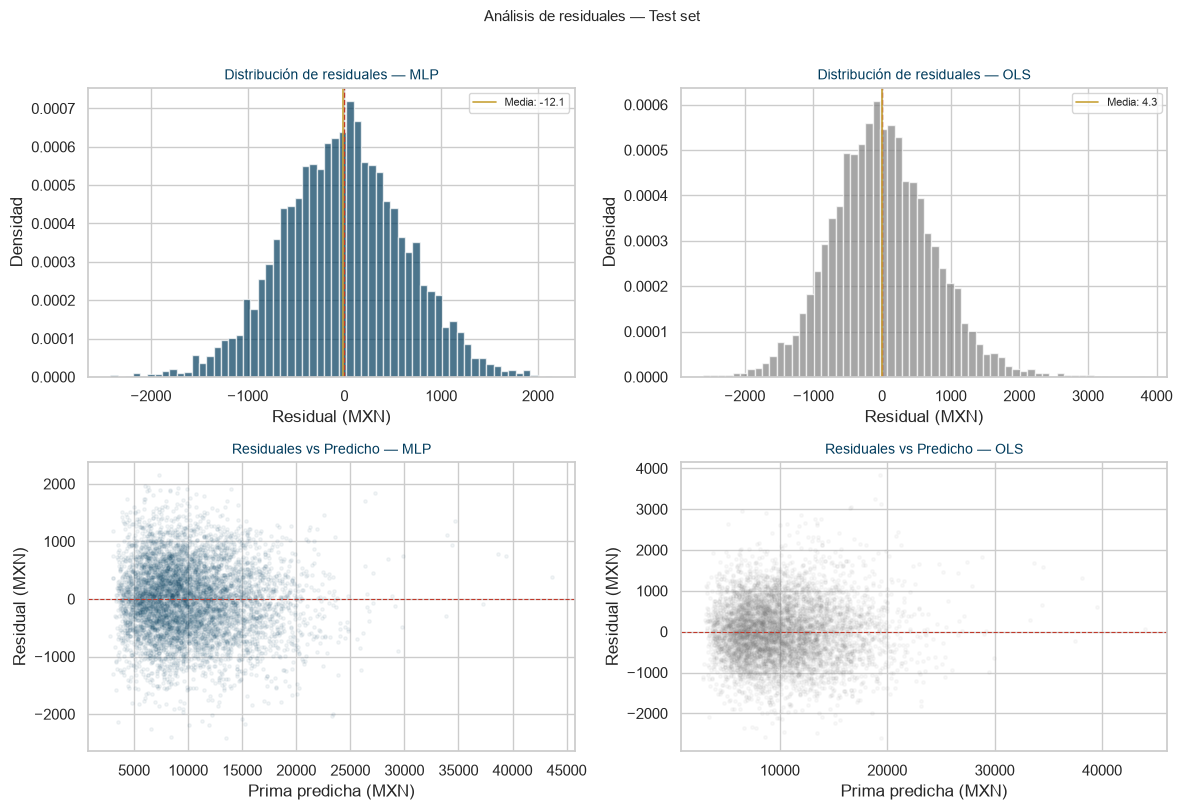

Residuales MLP — media: -12.05 | std: 632.9 MXN
Residuales OLS — media: +4.35  | std: 737.6 MXN

Diagnóstico cuantitativo (MLP): corr(predicción, |residual|) = 0.024
  Std de residuales por decil de predicción: 621–653 MXN

No se observa evidencia visual fuerte de un patrón de abanico; la dispersión por
deciles es aproximadamente estable. La ausencia de patrón visual no demuestra
especificación correcta; se requieren diagnósticos adicionales: colas,
observaciones influyentes y estabilidad fuera de muestra.


In [12]:
residuales_mlp = y_test.values - y_mlp_test
residuales_lr  = y_test.values - y_lr_test

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Distribución de residuales
for ax, resid, nombre, color in [
    (axes[0, 0], residuales_mlp, "MLP", NAVY),
    (axes[0, 1], residuales_lr,  "OLS", "gray"),
]:
    ax.hist(resid, bins=60, color=color, alpha=0.7, density=True)
    ax.axvline(0, color=RED, linewidth=1.0, linestyle="--")
    ax.axvline(resid.mean(), color=GOLD, linewidth=1.2,
               linestyle="-", label=f"Media: {resid.mean():.1f}")
    ax.set_xlabel("Residual (MXN)")
    ax.set_ylabel("Densidad")
    ax.set_title(f"Distribución de residuales — {nombre}",
                 fontsize=10, color=NAVY)
    ax.legend(fontsize=8)

# Residuales vs predicho (heterocedasticidad)
for ax, resid, y_pred, nombre, color in [
    (axes[1, 0], residuales_mlp, y_mlp_test, "MLP", NAVY),
    (axes[1, 1], residuales_lr,  y_lr_test,  "OLS", "gray"),
]:
    ax.scatter(y_pred, resid, alpha=0.05, s=6, color=color)
    ax.axhline(0, color=RED, linewidth=0.8, linestyle="--")
    ax.set_xlabel("Prima predicha (MXN)")
    ax.set_ylabel("Residual (MXN)")
    ax.set_title(f"Residuales vs Predicho — {nombre}",
                 fontsize=10, color=NAVY)

plt.suptitle("Análisis de residuales — Test set", fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

# Diagnóstico cuantitativo de heterocedasticidad (MLP) — no solo impresión visual (P3)
corr_pred_abs_resid = float(np.corrcoef(y_mlp_test, np.abs(residuales_mlp))[0, 1])
_decile_idx = pd.qcut(y_mlp_test, 10, labels=False, duplicates="drop")
_decile_std = pd.Series(residuales_mlp).groupby(_decile_idx).std()
resid_std_decile_min = float(_decile_std.min())
resid_std_decile_max = float(_decile_std.max())

print(f"Residuales MLP — media: {residuales_mlp.mean():+.2f} | std: {residuales_mlp.std():,.1f} MXN")
print(f"Residuales OLS — media: {residuales_lr.mean():+.2f}  | std: {residuales_lr.std():,.1f} MXN")
print()
print(f"Diagnóstico cuantitativo (MLP): corr(predicción, |residual|) = {corr_pred_abs_resid:.3f}")
print(f"  Std de residuales por decil de predicción: {resid_std_decile_min:,.0f}–{resid_std_decile_max:,.0f} MXN")
print()
print("No se observa evidencia visual fuerte de un patrón de abanico; la dispersión por")
print("deciles es aproximadamente estable. La ausencia de patrón visual no demuestra")
print("especificación correcta; se requieren diagnósticos adicionales: colas,")
print("observaciones influyentes y estabilidad fuera de muestra.")

## 13. Tabla resumen — configuraciones evaluadas en validation

Ver Sección 7b para el protocolo completo de selección. Esta sección consolida
los resultados de validación para facilitar la comparación.

> **Protocolo:** tres configuraciones entrenadas en `X_train_core` (19,200 obs.)
> y evaluadas en `X_val` (4,800 obs.). El test set (6,000 obs.) no se usó para
> la selección. La configuración con menor RMSE de validación se reentrenó sobre
> el `X_train` completo (24,000 obs.) — es el modelo evaluado en la Sección 10.

In [13]:
# Tabla resumen de resultados de validation (calculados en Sección 7b)
print("Tabla de selección — RMSE en validation (NO en test):")
print()
print(f"{'Configuración':<40} {'RMSE_val':>10} {'R²_val':>8} {'Épocas':>7}")
print("-" * 68)
for res in resultados_val:
    marca = " ← seleccionada" if res["label"] == best_val["label"] else ""
    print(f"  {res['label']:<38} {res['rmse_val']:>10,.1f} {res['r2_val']:>8.4f} {res['n_iter']:>7}{marca}")
print()
print(f"Modelo final (reentrenado sobre X_train completo, 24,000 obs.):")
print(f"  RMSE_test  = {rmse_mlp_test:,.1f} MXN   (test consultado UNA sola vez)")
print(f"  R²_test    = {r2_mlp_test:.4f}")
print()
print("Interpretación:")
print("• Las métricas de validation permiten seleccionar sin contaminar el test.")
print("• El reentrenamiento sobre el train completo puede cambiar las métricas")
print("  respecto a la evaluación en validation (más datos → puede mejorar o variar).")
print("• El RMSE_test es la estimación definitiva del desempeño sobre datos no vistos.")

Tabla de selección — RMSE en validation (NO en test):

Configuración                              RMSE_val   R²_val  Épocas
--------------------------------------------------------------------
  (64,32) α=0.001  [base]                     645.1   0.9745      43
  (128,64) α=0.001  [más parámetros]          655.5   0.9737      48
  (64,32) α=0.010  [más regularización]       637.5   0.9751      43 ← seleccionada

Modelo final (reentrenado sobre X_train completo, 24,000 obs.):
  RMSE_test  = 633.1 MXN   (test consultado UNA sola vez)
  R²_test    = 0.9779

Interpretación:
• Las métricas de validation permiten seleccionar sin contaminar el test.
• El reentrenamiento sobre el train completo puede cambiar las métricas
  respecto a la evaluación en validation (más datos → puede mejorar o variar).
• El RMSE_test es la estimación definitiva del desempeño sobre datos no vistos.


## 14. Comparación final: MLP vs referencias

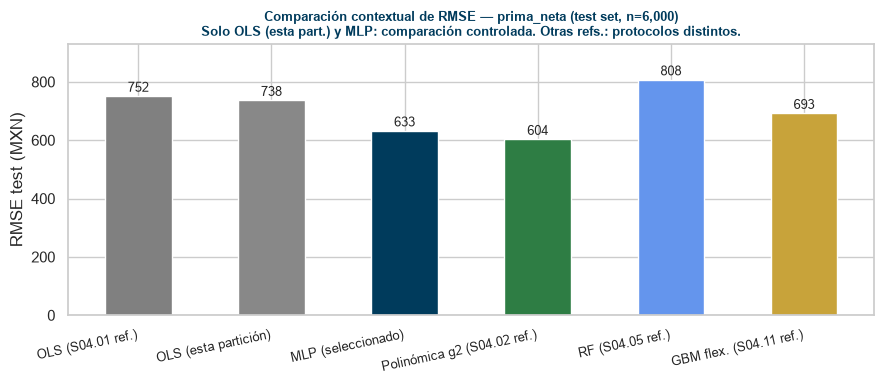

Comparación contextual — no estrictamente homogénea:
  Solo OLS (esta partición) y MLP tienen el mismo preprocesamiento dentro de S04.07.
  Polinómica, RF y GBM son referencias históricas con protocolos distintos.
  Polinómica grado 2 (RMSE≈604) obtiene menor RMSE que MLP:
  su forma funcional coincide con la estructura cuadrática del DGP.

  OLS (S04.01 ref.)              RMSE = 752 MXN
  OLS (esta partición)           RMSE = 738 MXN
  MLP (seleccionado)             RMSE = 633 MXN
  Polinómica g2 (S04.02 ref.)    RMSE = 604 MXN
  RF (S04.05 ref.)               RMSE = 808 MXN
  GBM flex. (S04.11 ref.)        RMSE = 693 MXN


In [14]:
# Comparación contextual de RMSE
RMSE_RF_REF   = 808.0
RMSE_GBM_REF  = 693.0
RMSE_OLS_REF  = 752.0
# Ref. S04.02 — Regresión polinómica grado 2 (misma semilla/partición)
# Fuente: data/outputs/notebook_checks/S04_A_regresion_validation.md
RMSE_POLY_REF = 604.0
R2_POLY_REF   = 0.9798

modelos_comp = [
    ("OLS (S04.01 ref.)",        RMSE_OLS_REF,  "gray"),
    ("OLS (esta partición)",     rmse_lr_test,  "#888888"),
    ("MLP (seleccionado)",       rmse_mlp_test, NAVY),
    ("Polinómica g2 (S04.02 ref.)", RMSE_POLY_REF, "#2E7D44"),
    ("RF (S04.05 ref.)",          RMSE_RF_REF,  "#6495ED"),
    ("GBM flex. (S04.11 ref.)",   RMSE_GBM_REF, GOLD),
]

fig, ax = plt.subplots(figsize=(9, 4))
colores = [m[2] for m in modelos_comp]
rmses   = [m[1] for m in modelos_comp]
nombres = [m[0] for m in modelos_comp]

bars = ax.bar(nombres, rmses, color=colores, edgecolor="white", width=0.5)
for bar, val in zip(bars, rmses):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f"{val:,.0f}", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("RMSE test (MXN)")
ax.set_title(
    "Comparación contextual de RMSE — prima_neta (test set, n=6,000)\n"
    "Solo OLS (esta part.) y MLP: comparación controlada. Otras refs.: protocolos distintos.",
    fontsize=9, color=NAVY, fontweight="bold")
ax.set_ylim([0, max(rmses) * 1.15])
plt.xticks(rotation=12, ha="right", fontsize=9)
plt.tight_layout()
plt.show()

print("Comparación contextual — no estrictamente homogénea:")
print("  Solo OLS (esta partición) y MLP tienen el mismo preprocesamiento dentro de S04.07.")
print("  Polinómica, RF y GBM son referencias históricas con protocolos distintos.")
print(f"  Polinómica grado 2 (RMSE≈{RMSE_POLY_REF:,.0f}) obtiene menor RMSE que MLP:")
print("  su forma funcional coincide con la estructura cuadrática del DGP.")
print()
# Comparación cuantitativa correcta (menor RMSE = mejor)
for nombre, rmse, _ in modelos_comp:
    print(f"  {nombre:<30} RMSE = {rmse:,.0f} MXN")

## 15. Conclusiones actuariales

In [15]:
print("=" * 65)
print("RESUMEN ACTUARIAL — MLP para tarificación de prima_neta")
print("=" * 65)
print()
print(f"Dataset: sintético v2, N={N:,} (SEED={SEED})")
print(f"Partición: 80/20 (train={X_train.shape[0]:,} | test={X_test.shape[0]:,})")
print(f"Selección: validation interna ({X_val.shape[0]:,} obs. de train, no test)")
print(f"Configuración seleccionada: {best_val['label']}")
print(f"  RMSE validation = {best_val['rmse_val']:,.1f} MXN")
print(f"  R² validation   = {best_val['r2_val']:.4f}")
print()
print(f"Resultados finales — Test set (evaluado una sola vez):")
print(f"  OLS (esta partición): RMSE={rmse_lr_test:,.1f} MXN | R²={r2_lr_test:.4f}")
print(f"  MLP seleccionado:     RMSE={rmse_mlp_test:,.1f} MXN | R²={r2_mlp_test:.4f}")
print()
print(f"Épocas de entrenamiento (modelo final): {mlp_raw.n_iter_}")
print(f"Parámetros del MLP: {sum(len(w.ravel()) for w in mlp_raw.coefs_):,} pesos + "
      f"{sum(len(b) for b in mlp_raw.intercepts_):,} sesgos")
print()
print("Interpretación actuarial:")
print(f"• En este dataset, el MLP obtiene menor RMSE que el OLS (esta partición)")
rmse_diff = rmse_lr_test - rmse_mlp_test
print(f"  en {rmse_diff:,.1f} MXN — diferencia moderada dado el DGP predominantemente aditivo con componente cuadrático.")
print(f"• El MLP también obtiene menor RMSE que GBM flex. ({RMSE_GBM_REF:,.0f} MXN),")
print(f"  aunque esta comparación no es estrictamente homogénea (S04-B usó GBM sin")
print(f"  la misma configuración de OHE/escalamiento que aquí).")
print(f"• Resultado condicional: este RMSE se obtiene con este dataset sintético,")
print(f"  esta arquitectura, este preprocesamiento y esta semilla. En datos reales")
print(f"  con mayor complejidad, los resultados podrían variar significativamente.")
print()
print(f"• Referencia contextual: Regresión polinómica grado 2 (S04.02) obtuvo RMSE≈{RMSE_POLY_REF:,.0f} MXN.")
print(f"  Obtiene menor RMSE que el MLP porque su forma funcional coincide con la estructura")
print(f"  cuadrática del DGP. Un modelo más complejo no necesariamente supera a uno cuya")
print(f"  forma funcional coincide con el DGP.")
print(f"• La curva de pérdida y el R² de validación interna confirman convergencia en esta ejecución (una semilla; el comportamiento puede variar).")
print(f"• La ausencia de un patrón visual dominante en los residuales no demuestra correcta")
print(f"  especificación. Se requieren diagnósticos adicionales: heterocedasticidad,")
print(f"  colas, observaciones influyentes y estabilidad fuera de muestra.")

RESUMEN ACTUARIAL — MLP para tarificación de prima_neta

Dataset: sintético v2, N=30,000 (SEED=20260618)
Partición: 80/20 (train=24,000 | test=6,000)
Selección: validation interna (4,800 obs. de train, no test)
Configuración seleccionada: (64,32) α=0.010  [más regularización]
  RMSE validation = 637.5 MXN
  R² validation   = 0.9751

Resultados finales — Test set (evaluado una sola vez):
  OLS (esta partición): RMSE=737.6 MXN | R²=0.9700
  MLP seleccionado:     RMSE=633.1 MXN | R²=0.9779

Épocas de entrenamiento (modelo final): 40
Parámetros del MLP: 4,000 pesos + 97 sesgos

Interpretación actuarial:
• En este dataset, el MLP obtiene menor RMSE que el OLS (esta partición)
  en 104.6 MXN — diferencia moderada dado el DGP predominantemente aditivo con componente cuadrático.
• El MLP también obtiene menor RMSE que GBM flex. (693 MXN),
  aunque esta comparación no es estrictamente homogénea (S04-B usó GBM sin
  la misma configuración de OHE/escalamiento que aquí).
• Resultado condicional: e

## 16. Limitaciones

1. **Explicabilidad:** a diferencia de OLS (coeficientes en MXN) o árboles (reglas),
   el MLP no produce parámetros directamente interpretables para un comité actuarial.

2. **Convergencia:** la función de pérdida no es convexa. `random_state` afecta el
   resultado final; se recomienda probar varias semillas si se usa en producción.

3. **Escalamiento fuertemente recomendado:** el escalamiento de features y del target
   es fuertemente recomendado para MLP: sin escalar, un objetivo o features de escala
   grande pueden dificultar la optimización (gradientes mal condicionados, necesidad de
   ajustar la tasa de aprendizaje) y la convergencia puede ser más lenta. No obstante,
   es una decisión de implementación, no una obligación matemática universal.

4. **Alcance de esta unidad:** se usa un MLP pequeño para datos tabulares. El término
   *deep learning* no tiene una frontera universal determinada únicamente por el número de capas.
   Las arquitecturas profundas especializadas (CNN, RNN, Transformer) quedan fuera del alcance
   de S04-C. Para datos tabulares en seguros, GBM suele obtener resultados competitivos
   con menos esfuerzo de ajuste.

5. **Sensibilidad a hiperparámetros:** `hidden_layer_sizes`, `alpha` y
   `learning_rate_init` deben ajustarse con validación interna, no con el test set.
   En este notebook se usó un conjunto de validación explícito (Sección 7b).

6. **Resultado condicional al dataset:** el RMSE del MLP en este dataset sintético
   puede no extrapolarse a datos reales con estructuras de dependencia distintas.
   La comparación con GBM, RF y Polinómica de S04-B/S04-A no es estrictamente homogénea
   (diferente preprocesamiento, feature engineering y protocolos); los resultados deben
   interpretarse con cautela.

## 17. Ejercicio propuesto

1. **Arquitectura más profunda:** cambia `hidden_layer_sizes=(128, 64, 32)` y `max_iter=800`.
   Usa la Sección 7b (validation interna) para comparar esta arquitectura con la seleccionada.
   ¿Mejora el RMSE de validación? Reporta el RMSE test solo al final, una sola vez.

2. **Sin escalamiento del target:** usa `MLPRegressor` directamente (sin
   `TransformedTargetRegressor`). ¿Cómo cambia la curva de pérdida en la primera época?
   ¿Cuántas iteraciones requiere para converger? ¿Por qué?

3. **Regularización:** entrena con `alpha=0` (sin regularización). Evalúa el sobreajuste
   usando **validación**: ¿RMSE_train es considerablemente menor que RMSE_validation?
   (El test no debe usarse para este diagnóstico — solo al final, una única vez.)
   ¿Cuántas épocas tarda en converger?

4. **Comparación con GBM:** el GBM flexible obtuvo RMSE≈693 MXN. ¿Con qué arquitectura
   MLP y cuántas épocas obtendrías un RMSE comparable? Usa solo validación interna
   para seleccionar, sin revisar el test set hasta el final.

---

### Referencias bibliográficas

- Géron, A. (2022). *Hands-On Machine Learning with Scikit-Learn, Keras & TensorFlow* (3rd ed.). O'Reilly. Cap. 10 §10.1–§10.2.
- Murphy, K. P. (2022). *Probabilistic Machine Learning: An Introduction*. MIT Press. Cap. 13.
- scikit-learn Developers. *User Guide* v1.9.0. `MLPRegressor`, `TransformedTargetRegressor`, `ColumnTransformer`.
- Wüthrich, M. V., & Buser, C. *Data Analytics for Non-Life Insurance Pricing*. Swiss Finance Institute. Cap. 2 (redes neuronales en pricing de seguros de no-vida).